<a href="https://colab.research.google.com/github/ghada-dahdoh/Applied-natural-language-processing/blob/main/Lap_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q torch transformers matplotlib

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt

from transformers import AutoModel, AutoTokenizer

In [ ]:
def attention(q, k, v, mask=None):
   d_k = q.size(-1)
   scores = torch.matmul(q, k.transpose(-2, -1))
   scores = scores / math.sqrt(d_k)
   if mask is not None:
       scores = scores.masked_fill(~mask, torch.finfo(scores.dtype).min)
   weights = torch.softmax(scores, dim=-1)
   output = torch.matmul(weights, v)
   return output, weights

In [ ]:

torch.manual_seed(123)

q = torch.randn(2, 5, 6, 8)
k = torch.randn(2, 5, 6, 8)
v = torch.randn(2, 5, 6, 8)

output_scratch, weights_scratch = attention(q, k, v)

output_pytorch = F.scaled_dot_product_attention(
    q, k, v
)

torch.testing.assert_close(
    output_scratch,
    output_pytorch,
    atol=1e-6,
    rtol=1e-6
)

print("Equivalence PASSED")

Equivalence PASSED


In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model=768, n_heads=8):
        super().__init__()

        assert d_model % n_heads == 0

        self.h = n_heads
        self.d_k = d_model // n_heads

        self.wq = nn.Linear(d_model, d_model)
        self.wk = nn.Linear(d_model, d_model)
        self.wv = nn.Linear(d_model, d_model)
        self.wo = nn.Linear(d_model, d_model)

    def forward(self, x, mask=None):
        b, n, _ = x.shape

        q = self.wq(x).view(
            b, n, self.h, self.d_k
        ).transpose(1, 2)

        k = self.wk(x).view(
            b, n, self.h, self.d_k
        ).transpose(1, 2)

        v = self.wv(x).view(
            b, n, self.h, self.d_k
        ).transpose(1, 2)

        out, weights = attention(q, k, v, mask)

        out = out.transpose(1, 2).contiguous().view(
            b, n, -1
        )

        return self.wo(out), weights

In [ ]:
GH = MultiHeadAttention()

n_params = sum(
    p.numel()
    for p in mha.parameters()
)

print(f"GH parameters: {n_params:,}")

GH parameters: 2,362,368


In [ ]:
model = AutoModel.from_pretrained(
    "bert-base-multilingual-cased"
)

buckets = {
    "embeddings": 0,
    "attention": 0,
    "feed-forward": 0,
    "other": 0
}

for name, p in model.named_parameters():

    if name.startswith("embeddings"):
        buckets["embeddings"] += p.numel()

    elif "attention" in name:
        buckets["attention"] += p.numel()

    elif "intermediate" in name or (
        "output" in name and "attention" not in name
    ):
        buckets["feed-forward"] += p.numel()

    else:
        buckets["other"] += p.numel()

total = sum(buckets.values())

for name, value in buckets.items():
    print(
        f"{name}: "
        f"{value/1e6:.1f}M "
        f"({value/total:.1%})"
    )

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  714MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


embeddings: 92.2M (51.8%)
attention: 28.4M (15.9%)
feed-forward: 56.7M (31.9%)
other: 0.6M (0.3%)


In [ ]:
model = AutoModel.from_pretrained(
    "CAMeL-Lab/bert-base-arabic-camelbert-mix"
)

buckets = {
    "embeddings": 0,
    "attention": 0,
    "feed-forward": 0,
    "other": 0
}

for name, p in model.named_parameters():

    if name.startswith("embeddings"):
        buckets["embeddings"] += p.numel()

    elif "attention" in name:
        buckets["attention"] += p.numel()

    elif "intermediate" in name or (
        "output" in name and "attention" not in name
    ):
        buckets["feed-forward"] += p.numel()

    else:
        buckets["other"] += p.numel()

total = sum(buckets.values())

for name, value in buckets.items():
    print(
        f"{name}: "
        f"{value/1e6:.1f}M "
        f"({value/total:.1%})"
    )

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: CAMeL-Lab/bert-base-arabic-camelbert-mix
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


embeddings: 23.4M (21.5%)
attention: 28.4M (26.0%)
feed-forward: 56.7M (52.0%)
other: 0.6M (0.5%)


In [ ]:
mask = torch.tril(
    torch.ones(
        1, 1, 5, 5,
        dtype=torch.bool
    )
)

print(mask[0, 0].int())

tensor([[1, 0, 0, 0, 0],
        [1, 1, 0, 0, 0],
        [1, 1, 1, 0, 0],
        [1, 1, 1, 1, 0],
        [1, 1, 1, 1, 1]], dtype=torch.int32)


In [ ]:
q = torch.randn(1, 1, 5, 8)
k = torch.randn(1, 1, 5, 8)
v = torch.randn(1, 1, 5, 8)

_, weights = attention(
    q, k, v, mask
)

print(weights[0, 0])

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.7189, 0.2811, 0.0000, 0.0000, 0.0000],
        [0.3522, 0.5711, 0.0767, 0.0000, 0.0000],
        [0.1571, 0.3020, 0.5222, 0.0187, 0.0000],
        [0.1089, 0.2883, 0.1845, 0.0801, 0.3382]])


In [ ]:
name = "CAMeL-Lab/bert-base-arabic-camelbert-mix"

tok = AutoTokenizer.from_pretrained(name)

model = AutoModel.from_pretrained(
    name,
    output_attentions=True
).eval()

text = "وصلت الحافلة إلى الجامعة في الصباح الباكر"

enc = tok(
    text,
    return_tensors="pt",
    padding="max_length",
    max_length=32
)

with torch.inference_mode():
    att = model(**enc).attentions

layer, head = 6, 2

weights = att[layer][0, head]

tokens = tok.convert_ids_to_tokens(
    enc.input_ids[0]
)

print(tokens)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: CAMeL-Lab/bert-base-arabic-camelbert-mix
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


['[CLS]', 'وصلت', 'الحا', '##فلة', 'إلى', 'الجامعة', 'في', 'الصباح', 'الباك', '##ر', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']


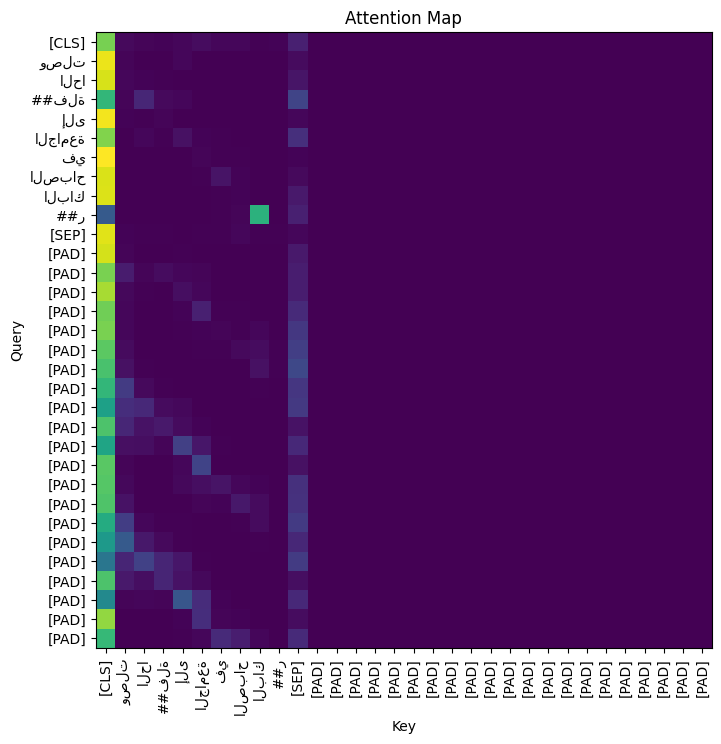

In [ ]:
plt.figure(figsize=(10, 8))

plt.imshow(
    weights.detach().numpy()
)

plt.xticks(
    range(len(tokens)),
    tokens,
    rotation=90
)

plt.yticks(
    range(len(tokens)),
    tokens
)

plt.xlabel("Key")
plt.ylabel("Query")
plt.title("Attention Map")

plt.show()

In [ ]:
pads = [
    i
    for i, t in enumerate(tokens)
    if t == "[PAD]"
]

print("PAD positions:", pads)

print(
    f"attention mass on PAD: "
    f"{weights[:, pads].sum():.4f}"
)

PAD positions: [11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
attention mass on PAD: 0.0000


In [ ]:
enc_no_mask = tok(
    text,
    return_tensors="pt",
    padding="max_length",
    max_length=32
)

enc_no_mask.pop("attention_mask")

with torch.inference_mode():
    att_no_mask = model(
        **enc_no_mask
    ).attentions

weights_no_mask = att_no_mask[
    layer
][0, head]

print(
    f"attention mass on PAD without mask: "
    f"{weights_no_mask[:, pads].sum():.4f}"
)

attention mass on PAD without mask: 1.1814
